<a href="https://colab.research.google.com/github/ManasaRubini/Internship/blob/main/Sleep_quality_prediction_using_SnowFlake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
!pip install snowflake-connector-python

In [ ]:
import snowflake.connector
con = snowflake.connector.connect(
    user = "ManasaRubini",
    password = "Shyaamghaneshgmk0206",
    account = "WDRBLRD-YE26672",
    database ="DETAILS",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [ ]:
query = 'select * from SleepQuality'
df = pd.read_sql(query,con)

/tmp/ipykernel_6048/2931347626.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,con)


In [ ]:
#EDA Process
df.head()

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,STRESSLEVEL,SLEEPDURATION,SLEEPQUALITY
0,6,38,2,High,9,Moderate
1,3,1,6,Low,9,Moderate
2,4,2,1,Medium,10,Moderate
3,6,112,1,Low,10,Moderate
4,2,100,6,Medium,4,Moderate


In [ ]:
df.tail()

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,STRESSLEVEL,SLEEPDURATION,SLEEPQUALITY
245,0,44,8,Medium,10,Moderate
246,1,19,1,High,4,Moderate
247,3,64,7,Medium,9,Moderate
248,3,7,1,High,8,Moderate
249,5,109,4,Medium,8,Moderate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CAFFEINE         250 non-null    int64 
 1   EXERCISEMINUTES  250 non-null    int64 
 2   SCREENTIMEHOURS  250 non-null    int64 
 3   STRESSLEVEL      250 non-null    object
 4   SLEEPDURATION    250 non-null    int64 
 5   SLEEPQUALITY     250 non-null    object
dtypes: int64(4), object(2)
memory usage: 11.8+ KB


In [ ]:
df.describe()

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,SLEEPDURATION
count,250.000000,250.000000,250.000000,250.00000
mean,3.092000,58.236000,3.888000,7.16400
std,2.014888,35.907125,2.530825,1.98415
min,0.000000,0.000000,0.000000,4.00000
25%,1.000000,26.250000,2.000000,6.00000
50%,3.000000,55.000000,4.000000,7.00000
75%,5.000000,92.000000,6.000000,9.00000
max,6.000000,120.000000,8.000000,10.00000


In [ ]:
df.shape

(250, 6)

In [ ]:
df.isnull().sum()

,0
CAFFEINE,0
EXERCISEMINUTES,0
SCREENTIMEHOURS,0
STRESSLEVEL,0
SLEEPDURATION,0
SLEEPQUALITY,0


In [ ]:
# Preprocessing
# no missing values
# Encoding the categorical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['STRESSLEVEL'] = le.fit_transform(df['STRESSLEVEL'])
df['SLEEPQUALITY'] = le.fit_transform(df['SLEEPQUALITY'])

In [ ]:
df

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,STRESSLEVEL,SLEEPDURATION,SLEEPQUALITY
0,6,38,2,0,9,2
1,3,1,6,1,9,2
2,4,2,1,2,10,2
3,6,112,1,1,10,2
4,2,100,6,2,4,2
...,...,...,...,...,...,...
245,0,44,8,2,10,2
246,1,19,1,0,4,2
247,3,64,7,2,9,2
248,3,7,1,0,8,2


In [ ]:
# identify the outliers
from scipy.stats import zscore

z  = zscore(df)
df[np.abs(z)>2.5]

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,STRESSLEVEL,SLEEPDURATION,SLEEPQUALITY


In [ ]:
# identify outliers
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3-q1
min = q1-1.5*iqr
max = q3+1.5*iqr
outlier = ((df<min)|(df>max)).any(axis=1)
df[outlier]

,CAFFEINE,EXERCISEMINUTES,SCREENTIMEHOURS,STRESSLEVEL,SLEEPDURATION,SLEEPQUALITY


<Axes: >

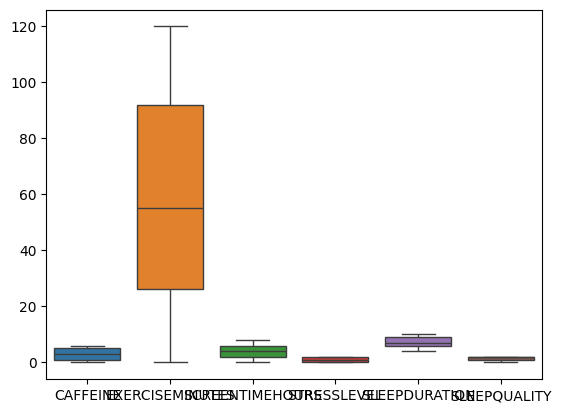

In [ ]:
# identify outliers
sns.boxplot(df)

In [ ]:
x = df.drop('SLEEPQUALITY',axis =1)
y = df['SLEEPQUALITY']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)
dtc = DecisionTreeClassifier(criterion='entropy',max_depth=100)
dtc.fit(x_train,y_train)
y_pred = dtc.predict(x_test)

print("Accuracy score = ",accuracy_score(y_pred,y_test))


Accuracy score =  0.76


In [ ]:
import graphviz
from sklearn import tree

data = tree.export_graphviz(
    dtc,
    out_file =None,
    feature_names=x.columns,
    class_names = ['good','moderate','bad'],
    filled = True,
    rounded = True,
    special_characters=True
)
graph = graphviz.Source(data)

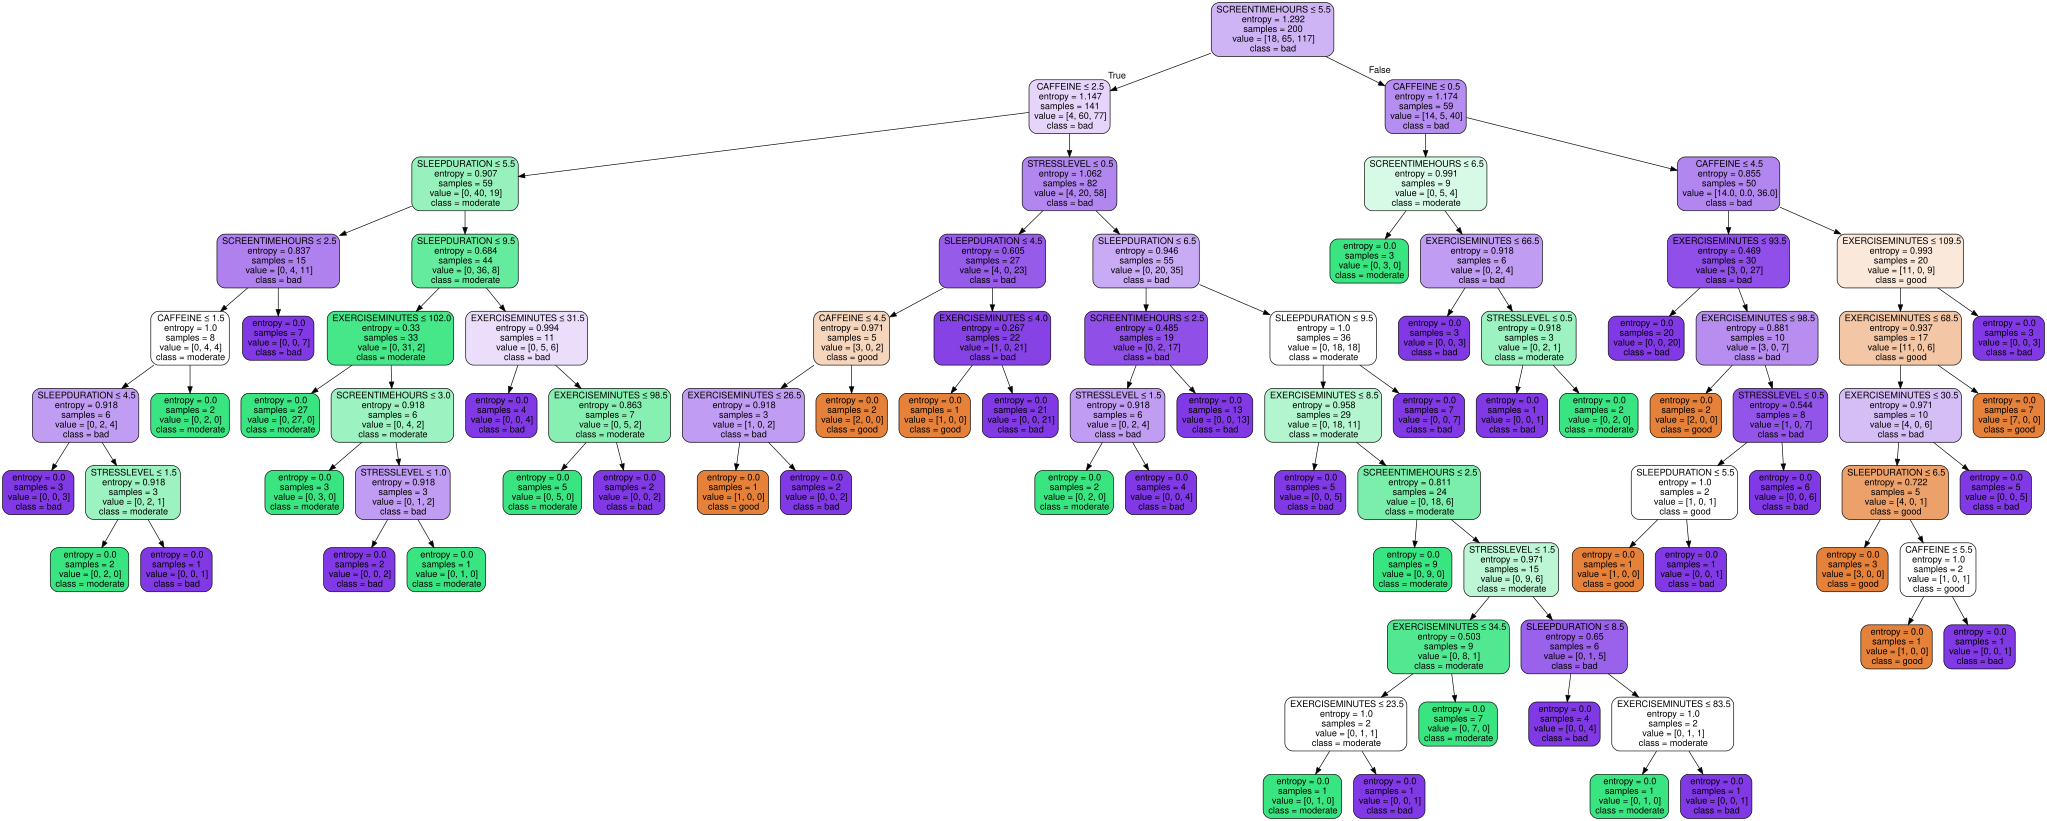

In [ ]:
graph